# ANC45 · P3HO₄ binding modes

This notebook follows up `enzyme_pha_analysis.ipynb` (Figures 1–6) for **ANC45 + P3HO₄ only**. It asks whether the PHA sits in two distinct binding modes, A (100–200 ns) and B (500–600 ns), which residues hold it in each, and how often an ester carbonyl lies next to the catalytic serine. Figure 9, the enzyme–PHA interaction energy, will be added in a later step. The summary at the end repeats the key numbers twice: for the two 100 ns windows, and for all frames labelled A or B in Figure 7.

**How to run:** select the **ipha_clean** kernel and choose Run All. The run takes about two minutes. Figures 7 and 8 use the existing residue-distance CSVs. Figures 10 and 11 also read the processed trajectory. Input files are only read. Every figure is saved as a 400 dpi PNG and a CSV in a new `analysis/binding_modes_ANC45/<RUN_TAG>/` folder. An existing folder is never overwritten.

In [1]:
from pathlib import Path
from datetime import datetime
import os, json, hashlib, tempfile, shutil, platform, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.transforms import ScaledTranslation
from IPython.display import display, Markdown

# ===== EDIT HERE: the only configuration cell =====
BASE_DIR = Path('/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme')
SYSTEM_FOLDER = 'ANC45_P3HO_4_gromacs'
SOURCE_TAG = 'research_0_1000ns'                 # tag of the existing Figure 3 and Figure 5-6 CSVs
TPR_NAME = 'step7_production.tpr'
TRAJECTORY_NAME = 'processed_protein_centered.xtc'   # in analysis/; 0-1000 ns used, 0.1 ns frames
RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')   # or a fixed name; an existing folder is never overwritten
OUTPUT_ROOT = Path(os.environ.get('ANC45_BINDING_MODES_OUTPUT_ROOT',
                                  BASE_DIR / SYSTEM_FOLDER / 'analysis' / 'binding_modes_ANC45'))
OUTPUT_DIR = OUTPUT_ROOT / RUN_TAG

WINDOWS = {'A': (100.0, 200.0), 'B': (500.0, 600.0)}    # ns (B was 400-500 ns in run 20261005_134811)
CONTACT_CUTOFF_A = 3.5                                   # residue-PHA contact cutoff (Å)
WIDE_CUTOFF_A = 4.5                                      # looser contact cutoff, Figure 10 only (Å)
TRIAD = {'SER138': ('SER', 138), 'ASP194': ('ASP', 194), 'HSD226': ('HSD', 226)}

SMOOTH_NS = 2.0                       # Figure 7: centred rolling mean of contact fingerprints
SMOOTH_SENSITIVITY_NS = (1.0, 5.0)    # Figure 7: sensitivity check
START_POSE_NS = 5.0                   # Figure 7: starting-pose check uses the first 5 ns
SIMILARITY_THRESHOLD = 0.5            # Figure 7: minimum cosine similarity for state A or B
MIN_SEGMENT_NS = 5.0                  # Figure 7: shorter segments merged, for residence statistics only
TOP_N, PROMINENT_PERCENT = 10, 10.0   # Figure 8: top 10 in either window, or >= 10 %
HBOND_DA_CUTOFF_A, HBOND_ANGLE_DEG = 3.0, 150.0   # Figure 10: donor-acceptor distance, D-H-A angle
READY_CUTOFF_A = 3.5                  # Figure 11: d1 and d2 must both be within this distance

COLOURS = {'A': 'tab:blue', 'B': 'tab:orange', 'transition': '0.6', 'unbound': 'white'}
TRIAD_COLOUR = 'tab:red'
FIGSIZE, PNG_DPI = (8, 4.5), 400

plt.rcdefaults()
plt.rcParams.update({'figure.figsize': FIGSIZE, 'savefig.dpi': PNG_DPI,
                     'axes.spines.left': True, 'axes.spines.bottom': True,
                     'axes.spines.top': False, 'axes.spines.right': False})
SYSTEM_DIR = BASE_DIR / SYSTEM_FOLDER
STATES = ['A', 'B', 'transition', 'unbound']
(a0, a1), (b0, b1) = WINDOWS['A'], WINDOWS['B']
if not (0 <= a0 < a1 <= b0 < b1 <= 1000):
    raise ValueError('Windows must be ordered, non-overlapping and inside 0-1000 ns')
print('Run tag:', RUN_TAG, '| output:', OUTPUT_DIR)

Run tag: 20261005_144534 | output: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HO_4_gromacs/analysis/binding_modes_ANC45/20261005_144534


### Helper functions

The loading, time-weighting and file-check helpers are copied unchanged from `enzyme_p3ho4_binding_modes.ipynb`, so occupancies match that notebook. The save helpers refuse to replace an existing file.

In [2]:
def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda: f.read(1024*1024), b''): h.update(chunk)
    return h.hexdigest()

def file_record(path, digest=False):
    path = Path(path); stat = path.stat()
    result = {'path': str(path.resolve()), 'size': stat.st_size, 'mtime_ns': stat.st_mtime_ns}
    if digest: result['sha256'] = sha256(path)
    return result

def validate_times(times):
    t = np.asarray(times, float)
    if t.ndim != 1 or len(t) < 2 or not np.isfinite(t).all() or np.any(np.diff(t) <= 0):
        raise ValueError('Need finite strictly increasing times, with at least two samples')
    return t

def clip_series(times, values, start, end):
    t = validate_times(times); v = np.asarray(values, float)
    if v.shape[0] != len(t) or not np.isfinite(v).all() or not t[0] <= start < end <= t[-1]:
        raise ValueError('Invalid data or requested window outside real sampled coverage')
    inner = (t > start) & (t < end)
    matrix = v.reshape(len(t), -1)
    out = np.vstack(([np.interp(start, t, col) for col in matrix.T], matrix[inner],
                     [np.interp(end, t, col) for col in matrix.T]))
    return np.r_[start, t[inner], end], out.reshape((len(out),) + v.shape[1:])

def contact_duration(times, distances, cutoff):
    # Time at or below the cutoff, with linear interpolation of cutoff crossings.
    t = validate_times(times); d = np.asarray(distances, float)
    if d.shape[0] != len(t) or not np.isfinite(d).all() or np.any(d < 0) or not np.isfinite(cutoff) or cutoff <= 0:
        raise ValueError('Invalid distances or cutoff')
    left, right = d[:-1], d[1:]; il, ir = left <= cutoff, right <= cutoff
    fraction = (il & ir).astype(float); crossing = il != ir
    f = (cutoff - left[crossing]) / (right[crossing] - left[crossing])
    fraction[crossing] = np.where(il[crossing], f, 1 - f)
    dt = np.diff(t).reshape((-1,) + (1,) * (d.ndim - 1))
    return np.sum(dt * np.clip(fraction, 0, 1), axis=0)

def check_raw_provenance(paths, meta):
    for key in ('tpr', 'xtc'):
        if paths[key].resolve() != Path(meta['inputs'][key]).resolve(): raise ValueError('Source path changed')
        rec = file_record(paths[key])
        if [rec['size'], rec['mtime_ns']] != meta['input_size_mtime_ns'][key]:
            raise ValueError(f'{key}: source differs from saved provenance')

def check_distances(d, residues, global_data):
    cols = residues.distance_column.tolist()
    if d.columns.tolist() != ['frame', 'time_ns'] + cols or len(cols) != len(set(cols)) or residues.resindex.duplicated().any():
        raise ValueError('Residue identifiers do not match distance schema')
    validate_times(d.time_ns)
    if not np.isfinite(d[cols]).all().all() or (d[cols] < 0).any().any(): raise ValueError('Invalid distances')
    g = global_data.set_index('frame').loc[d.frame]
    if not np.allclose(g.time_ns, d.time_ns, atol=1e-8, rtol=0) or not np.allclose(g.enzyme_pha_min_distance_A, d[cols].min(axis=1), atol=2e-5, rtol=0):
        raise ValueError('All-residue minima do not reproduce global distances/frames')

def window_occupancy(window, cutoff=CONTACT_CUTOFF_A):
    # Time-weighted % of the window that each residue spends within the cutoff of the PHA.
    start, end = window
    t, v = clip_series(T, DIST, start, end)
    return 100 * contact_duration(t, v, cutoff) / (end - start)

def in_window(times, window):
    return (np.asarray(times) >= window[0]) & (np.asarray(times) <= window[1])

def save_csv(table, name):
    path = OUTPUT_DIR / name
    if path.exists(): raise FileExistsError(f'Refusing to overwrite {path}')
    table.to_csv(path, index=False); SAVED.append(path)

def save_png(fig, name):
    path = OUTPUT_DIR / name
    if path.exists(): raise FileExistsError(f'Refusing to overwrite {path}')
    fig.savefig(path, dpi=PNG_DPI); SAVED.append(path)

def tidy(ax):
    ax.set_axisbelow(True); ax.grid(alpha=0.3)

def shade_windows(ax):
    for label, (start, end) in WINDOWS.items():
        ax.axvspan(start, end, color=COLOURS[label], alpha=0.12, lw=0)

def draw_state_strip(ax, labels):
    codes = np.array([STATES.index(s) for s in labels])
    ax.imshow(codes[None, :], aspect='auto', interpolation='nearest', vmin=-0.5, vmax=3.5,
              cmap=ListedColormap([COLOURS[s] for s in STATES]), extent=[EDGES[0], EDGES[-1], 0, 1])
    ax.set_yticks([]); ax.spines['right'].set_visible(True); ax.spines['top'].set_visible(True)
    handles = [Patch(facecolor=COLOURS[s], edgecolor='k', lw=0.5, label=s) for s in STATES]
    below = ax.transAxes + ScaledTranslation(0, -0.5, ax.figure.dpi_scale_trans)   # 0.5 inch under the strip
    ax.legend(handles=handles, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 0), bbox_transform=below, frameon=False)

# Analytic checks of the copied helpers: uneven intervals, exact cutoff.
assert np.isclose(contact_duration([0, 3, 10], np.array([2, 2, 5]), 3.5), 6.5)
assert contact_duration([0, 10], np.array([3.5, 3.5]), 3.5) == 10

### Load inputs and check the catalytic triad

This cell checks that the CSVs and the trajectory are the files that produced Figures 3, 5 and 6. It also checks that SER138, ASP194 and HSD226 exist with these names and numbers in both the residue table and the TPR. It stops with a message, before any figure is made, if anything is missing.

In [3]:
import MDAnalysis as mda

prefix = SYSTEM_DIR / 'analysis' / f"{SYSTEM_FOLDER.removesuffix('_gromacs')}_{SOURCE_TAG}"
PATHS = {'tpr': SYSTEM_DIR / TPR_NAME, 'xtc': SYSTEM_DIR / 'analysis' / TRAJECTORY_NAME,
         'global': Path(f'{prefix}_enzyme_pha_min_distance.csv'), 'summary': Path(f'{prefix}_summary.json'),
         'distances': Path(f'{prefix}_residue_pha_distances_A.csv'),
         'residues': Path(f'{prefix}_residue_pha_residues.csv'), 'metadata': Path(f'{prefix}_residue_pha_metadata.json')}
missing = [str(p) for p in PATHS.values() if not p.is_file()]
if missing:
    raise FileNotFoundError('Missing input files:\n' + '\n'.join(missing))

# 1. Inputs are the files that produced Figures 3, 5 and 6.
summary_json = json.loads(PATHS['summary'].read_text()); metadata_json = json.loads(PATHS['metadata'].read_text())
check_raw_provenance(PATHS, summary_json); check_raw_provenance(PATHS, metadata_json)
for key, hashkey in [('distances', 'distance_csv_sha256'), ('residues', 'residue_csv_sha256'), ('global', 'figure3_sha256')]:
    if sha256(PATHS[key]) != metadata_json[hashkey]:
        raise ValueError(f'{PATHS[key].name} changed since the residue analysis was saved')
global_data = pd.read_csv(PATHS['global'], usecols=['frame', 'time_ns', 'enzyme_pha_min_distance_A'])
distances = pd.read_csv(PATHS['distances'])
residues = pd.read_csv(PATHS['residues'], keep_default_na=False)
check_distances(distances, residues, global_data)

FRAMES = distances.frame.to_numpy()
T = distances.time_ns.to_numpy()
DIST = distances[residues.distance_column].to_numpy()          # frames x residues, Å
GMIN = global_data.set_index('frame').loc[FRAMES, 'enzyme_pha_min_distance_A'].to_numpy()
DT = float(np.median(np.diff(T)))
EDGES = np.r_[T[0], (T[:-1] + T[1:]) / 2, T[-1]]               # each frame stands for the time to its neighbours' midpoints
RES_LABELS = (residues.resname + residues.resid.astype(str)).to_numpy()
if not (np.array_equal(FRAMES, np.arange(FRAMES[0], FRAMES[0] + len(FRAMES))) and np.allclose(np.diff(T), DT, atol=1e-6)):
    raise ValueError('Expected contiguous frames with uniform spacing')

# 2. Catalytic triad in the residue table and in the TPR.
problems = []
for label, (resname, resid) in TRIAD.items():
    hit = residues.loc[residues.resid == resid]
    if len(hit) != 1 or hit.resname.iloc[0] != resname:
        problems.append(f'residue table: expected {resname}{resid}, found {hit.resname.tolist()}')
SCRATCH = Path(tempfile.mkdtemp(prefix='anc45_binding_modes_'))
(SCRATCH / 'trajectory.xtc').symlink_to(PATHS['xtc'])   # keeps MDAnalysis offset files out of the data folder
U = mda.Universe(str(PATHS['tpr']), str(SCRATCH / 'trajectory.xtc'))
REQUIRED_ATOMS = {'SER138': ['OG'], 'ASP194': ['OD1', 'OD2'], 'HSD226': ['NE2', 'ND1']}
ATOMS = {}
for label, names in REQUIRED_ATOMS.items():
    resname, resid = TRIAD[label]
    res = U.select_atoms(f'protein and resid {resid}').residues
    if len(res) != 1 or res.resnames[0] != resname:
        problems.append(f'TPR: expected {resname}{resid}, found {list(res.resnames)}'); continue
    for name in names:
        atom = res.atoms.select_atoms(f'name {name}')
        if len(atom) != 1: problems.append(f'TPR: {label} has no single atom {name}')
        ATOMS[f'{label}_{name}'] = atom
LIG = U.select_atoms('resname LIG')
CARBONYL_C = LIG.select_atoms('type CG2O2')
if len(CARBONYL_C) != 4:
    problems.append(f'TPR: LIG has {len(CARBONYL_C)} carbonyl carbons of type CG2O2, expected 4')
if problems:
    raise RuntimeError('Checks failed, so no figures were made:\n- ' + '\n- '.join(problems))
for i in (0, len(T) // 2, len(T) - 1):
    if not np.isclose(U.trajectory[int(FRAMES[i])].time / 1000, T[i], atol=1e-6):
        raise ValueError('Trajectory frame times do not match the CSV')

# Ester carbonyl carbons are bonded to an ester oxygen (OG302); the chain-end acid carbon to an OH (OG311).
CARBONYL_KIND = {a.name: ('ester' if 'OG302' in a.bonded_atoms.types else 'acid end')
                 for a in CARBONYL_C}

if OUTPUT_DIR.exists():
    raise FileExistsError(f'{OUTPUT_DIR} already exists; choose a new RUN_TAG')
OUTPUT_DIR.mkdir(parents=True)
SAVED = []
print(f'Checks passed: {len(residues)} residues, {len(T)} frames ({T[0]:g}-{T[-1]:g} ns, every {DT:g} ns).')
print('Triad atoms:', ', '.join(ATOMS), '| LIG CG2O2 carbons:', CARBONYL_KIND)

/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checks passed: 244 residues, 10001 frames (0-1000 ns, every 0.1 ns).
Triad atoms: SER138_OG, ASP194_OD1, ASP194_OD2, HSD226_NE2, HSD226_ND1 | LIG CG2O2 carbons: {'C16': 'ester', 'C8': 'ester', 'C24': 'ester', 'C32': 'acid end'}


### Figure 7 — State timeline (0–1000 ns)

**Question:** when is the PHA in state A, in state B, switching between them, or unbound, and how long does each state last? Each frame's residue contacts (≤3.5 Å) are smoothed over 2 ns and compared, by cosine similarity, with the contact profiles of window A and window B. **How to read it:** the top panel is the minimum enzyme–PHA distance, the middle panel shows how closely the contacts match A (blue) or B (orange), and the strip shows the assigned state. The longest clean A and B blocks, and the unbound stretch between them, are marked on the top panel. Segments shorter than 5 ns are merged into their neighbours for the residence table only; the strip shows unmerged labels.

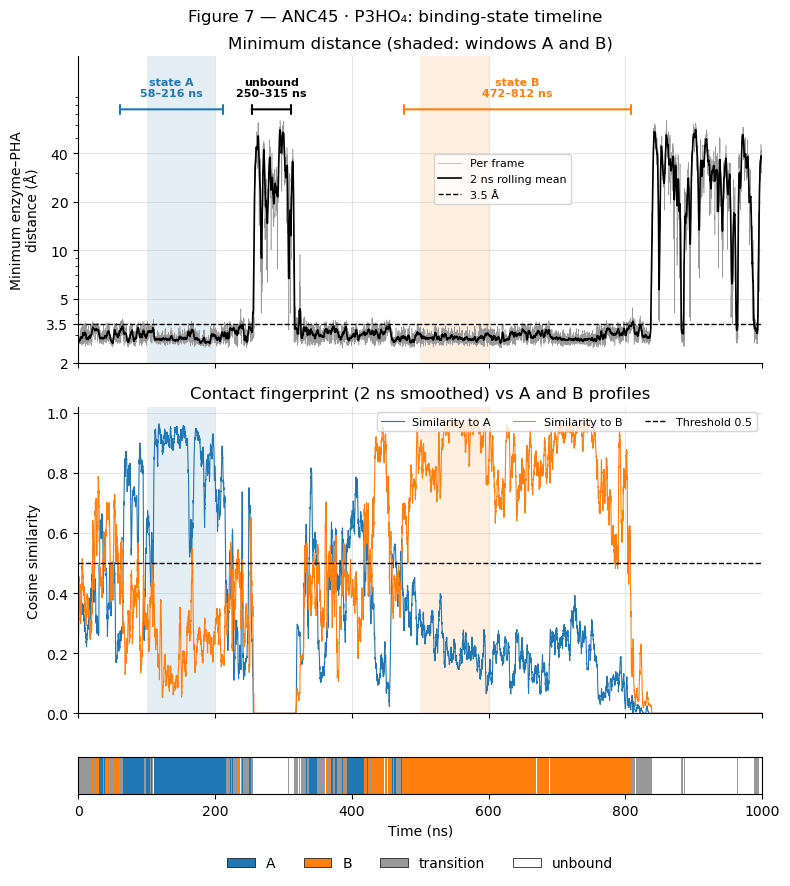

Similarity between the A and B reference profiles themselves: 0.22

Smoothing 2 ns (main)


,state,total_time_ns,time_after_merging_ns,segments,longest_segment_ns,longest_from_ns,longest_to_ns
0,A,206.4,222.6,6,157.8,57.8,215.6
1,B,402.9,412.9,4,340.6,471.6,812.2
2,transition,156.8,146.9,9,33.9,215.6,249.6
3,unbound,233.9,217.6,4,101.6,886.0,987.6


State changes (transition segments skipped): B → A at ~31.2 ns; A → B at ~36.7 ns; B → A at ~57.8 ns; A → unbound → A (249.6–315.4 ns); A → B at ~417.8 ns; B → A at ~458.6 ns; A → B (464.4–471.6 ns); B → unbound (to end of run) (837.4–1000 ns)

Smoothing 1 ns (sensitivity)


,state,total_time_ns,time_after_merging_ns,segments,longest_segment_ns,longest_from_ns,longest_to_ns
0,A,198.5,206.9,5,151.3,64.6,215.8
1,B,394.5,407.3,5,340.1,472.2,812.2
2,transition,173.0,168.2,11,33.7,215.8,249.6
3,unbound,233.9,217.6,4,101.6,886.0,987.6


State changes (transition segments skipped): B → A at ~31 ns; A → B at ~39.8 ns; B → A (58.8–64.6 ns); A → unbound → A (249.6–315.4 ns); A → B at ~417.6 ns; B → unbound (to end of run) (837.4–1000 ns)

Smoothing 5 ns (sensitivity)


,state,total_time_ns,time_after_merging_ns,segments,longest_segment_ns,longest_from_ns,longest_to_ns
0,A,218.2,223.1,6,152.2,64.6,216.8
1,B,416.5,416.4,6,335.0,471.0,806.0
2,transition,131.4,142.2,10,32.1,216.8,248.8
3,unbound,233.9,218.3,4,101.6,886.0,987.6


State changes (transition segments skipped): B → A at ~32 ns; A → B at ~38.2 ns; B → A (58.8–64.6 ns); A → unbound → A (248.8–315.4 ns); A → B (352.4–362.6 ns); B → A at ~368.2 ns; A → B (378.8–387 ns); B → A at ~392.2 ns; A → B at ~418.4 ns; B → A at ~459 ns; A → B (465.2–471 ns); B → unbound (to end of run) (837.4–1000 ns)

Starting pose (mean fingerprint, 0–5 ns): similarity to A = 0.42, to B = 0.35 → resembles neither (both below 0.5); slightly closer to A


In [4]:
PROFILES = {k: window_occupancy(w) / 100 for k, w in WINDOWS.items()}   # residue occupancy, 0-1
CONTACT = (DIST <= CONTACT_CUTOFF_A).astype(float)

def label_states(smooth_ns):
    n = int(round(smooth_ns / DT)) + 1       # centred window spanning smooth_ns
    smooth = pd.DataFrame(CONTACT).rolling(n, center=True, min_periods=1).mean().to_numpy()
    norm = np.linalg.norm(smooth, axis=1)
    sim = {k: np.divide(smooth @ p, norm * np.linalg.norm(p), out=np.zeros(len(T)), where=norm > 0)
           for k, p in PROFILES.items()}
    labels = np.full(len(T), 'transition', dtype=object)
    labels[(sim['A'] > sim['B']) & (sim['A'] >= SIMILARITY_THRESHOLD)] = 'A'
    labels[(sim['B'] > sim['A']) & (sim['B'] >= SIMILARITY_THRESHOLD)] = 'B'
    labels[GMIN > CONTACT_CUTOFF_A] = 'unbound'
    return sim['A'], sim['B'], labels

def segments(labels):
    cut = np.flatnonzero(labels[1:] != labels[:-1]) + 1
    return [{'state': labels[s], 'first': s, 'last': e - 1, 'start_ns': EDGES[s], 'end_ns': EDGES[e]}
            for s, e in zip(np.r_[0, cut], np.r_[cut, len(labels)])]

def merge_short(segs, min_ns):
    # Repeatedly give the shortest too-short segment to its neighbours (same state on both sides, else the longer one).
    segs = [dict(s) for s in segs]
    while len(segs) > 1:
        dur = [s['end_ns'] - s['start_ns'] for s in segs]
        i = int(np.argmin(dur))
        if dur[i] >= min_ns: break
        left = segs[i-1] if i > 0 else None; right = segs[i+1] if i < len(segs) - 1 else None
        if left and right:
            segs[i]['state'] = left['state'] if (left['state'] == right['state'] or dur[i-1] >= dur[i+1]) else right['state']
        else:
            segs[i]['state'] = (left or right)['state']
        merged = []
        for s in segs:
            if merged and merged[-1]['state'] == s['state']:
                merged[-1].update(last=s['last'], end_ns=s['end_ns'])
            else:
                merged.append(dict(s))
        segs = merged
    return segs

def residence(labels, smooth_ns):
    segs = merge_short(segments(labels), MIN_SEGMENT_NS); widths = np.diff(EDGES); rows = []
    for state in STATES:
        mine = [s for s in segs if s['state'] == state]
        dur = [s['end_ns'] - s['start_ns'] for s in mine]
        best = mine[int(np.argmax(dur))] if mine else None
        rows.append({'smoothing_ns': smooth_ns, 'state': state,
                     'total_time_ns': round(float(widths[labels == state].sum()), 1),
                     'time_after_merging_ns': round(float(sum(dur)), 1), 'segments': len(mine),
                     'longest_segment_ns': round(max(dur), 1) if dur else 0.0,
                     'longest_from_ns': round(best['start_ns'], 1) if best else np.nan,
                     'longest_to_ns': round(best['end_ns'], 1) if best else np.nan})
    transitions = pd.DataFrame([{'smoothing_ns': smooth_ns, 'from': a['state'], 'to': b['state'],
                                 'time_ns': round(b['start_ns'], 1)} for a, b in zip(segs[:-1], segs[1:])])
    return pd.DataFrame(rows), transitions, segs

def state_changes(segs, smooth_ns):
    # Drop transition segments, then list changes between A, B and unbound; an unbound stretch is shown as X → unbound → Y.
    seq = []
    for s in segs:
        if s['state'] == 'transition': continue
        if seq and seq[-1]['state'] == s['state']: seq[-1]['end_ns'] = s['end_ns']
        else: seq.append(dict(s))
    rows, i = [], 0
    while i < len(seq) - 1:
        a, b = seq[i], seq[i + 1]
        if b['state'] == 'unbound':
            c = seq[i + 2] if i + 2 < len(seq) else None
            change = f"{a['state']} → unbound → {c['state']}" if c else f"{a['state']} → unbound (to end of run)"
            rows.append({'smoothing_ns': smooth_ns, 'change': change, 'from_ns': round(b['start_ns'], 1), 'to_ns': round(b['end_ns'], 1)})
            i += 2
        else:
            rows.append({'smoothing_ns': smooth_ns, 'change': f"{a['state']} → {b['state']}",
                         'from_ns': round(a['end_ns'], 1), 'to_ns': round(b['start_ns'], 1)})
            i += 1
    return pd.DataFrame(rows, columns=['smoothing_ns', 'change', 'from_ns', 'to_ns'])

def describe_changes(changes):
    return '; '.join(f"{r.change} ({r.from_ns:g}–{r.to_ns:g} ns)" if r.to_ns - r.from_ns > 0.05 else f"{r.change} at ~{r.from_ns:g} ns"
                     for r in changes.itertuples())

results7 = {}
for s_ns in (SMOOTH_NS,) + tuple(SMOOTH_SENSITIVITY_NS):
    simA, simB, labels = label_states(s_ns)
    table, transitions, segs = residence(labels, s_ns)
    results7[s_ns] = {'simA': simA, 'simB': simB, 'labels': labels, 'table': table,
                      'transitions': transitions, 'segments': segs, 'changes': state_changes(segs, s_ns)}
main7 = results7[SMOOTH_NS]; STATE_LABELS = main7['labels']
merged_labels = np.empty(len(T), dtype=object)
for s in main7['segments']: merged_labels[s['first']:s['last'] + 1] = s['state']

n_roll = int(round(SMOOTH_NS / DT)) + 1
gmin_roll = pd.Series(GMIN).rolling(n_roll, center=True, min_periods=1).mean().to_numpy()
fig, axes = plt.subplots(3, 1, figsize=(FIGSIZE[0], 2 * FIGSIZE[1]), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1, 0.12]})
ax = axes[0]; shade_windows(ax)
ax.plot(T, GMIN, color='0.6', lw=0.4, label='Per frame')
ax.plot(T, gmin_roll, color='k', lw=1.2, label=f'{SMOOTH_NS:g} ns rolling mean')
ax.axhline(CONTACT_CUTOFF_A, color='k', ls='--', lw=1, label=f'{CONTACT_CUTOFF_A:g} Å')
ax.set_yscale('log'); ax.set_yticks([2, 3.5, 5, 10, 20, 40]); ax.set_yticklabels(['2', '3.5', '5', '10', '20', '40'])
ax.set(ylabel='Minimum enzyme–PHA\ndistance (Å)', ylim=(2, 160), title='Minimum distance (shaded: windows A and B)')
ax.legend(loc='center', bbox_to_anchor=(0.62, 0.6), fontsize=8); tidy(ax)
# Mark the longest clean A and B blocks and any unbound stretch (>= 20 ns) between them, from the merged labels.
def longest(state):
    c = [s for s in main7['segments'] if s['state'] == state]
    return max(c, key=lambda s: s['end_ns'] - s['start_ns']) if c else None
blocks = [(longest(k), f'state {k}', COLOURS[k]) for k in ('A', 'B') if longest(k)]
if len(blocks) == 2:
    gap = sorted([blocks[0][0], blocks[1][0]], key=lambda s: s['start_ns'])
    blocks += [(s, 'unbound', 'k') for s in main7['segments'] if s['state'] == 'unbound'
               and s['start_ns'] >= gap[0]['end_ns'] and s['end_ns'] <= gap[1]['start_ns'] and s['end_ns'] - s['start_ns'] >= 20]
ANNOTATED_BLOCKS = []
for seg, name, colour in blocks:
    ax.annotate('', xy=(seg['start_ns'], 75), xytext=(seg['end_ns'], 75),
                arrowprops=dict(arrowstyle='|-|', color=colour, lw=1.5, mutation_scale=3))
    ax.text((seg['start_ns'] + seg['end_ns']) / 2, 88, f"{name}\n{seg['start_ns']:.0f}–{seg['end_ns']:.0f} ns",
            ha='center', va='bottom', fontsize=8, color=colour, fontweight='bold')
    ANNOTATED_BLOCKS.append({'label': name, 'start_ns': round(seg['start_ns'], 1), 'end_ns': round(seg['end_ns'], 1)})
ax = axes[1]; shade_windows(ax)
ax.plot(T, main7['simA'], color=COLOURS['A'], lw=0.8, label='Similarity to A')
ax.plot(T, main7['simB'], color=COLOURS['B'], lw=0.8, label='Similarity to B')
ax.axhline(SIMILARITY_THRESHOLD, color='k', ls='--', lw=1, label=f'Threshold {SIMILARITY_THRESHOLD:g}')
ax.set(ylabel='Cosine similarity', ylim=(0, 1.02), title=f'Contact fingerprint ({SMOOTH_NS:g} ns smoothed) vs A and B profiles')
ax.legend(loc='upper right', fontsize=8, ncol=3); tidy(ax)
draw_state_strip(axes[2], STATE_LABELS)
axes[2].set(xlabel='Time (ns)', xlim=(T[0], T[-1]))
fig.suptitle('Figure 7 — ANC45 · P3HO₄: binding-state timeline')
fig.tight_layout()
save_png(fig, 'fig7_state_timeline.png')
display(fig); plt.close(fig)

save_csv(pd.DataFrame({'frame': FRAMES, 'time_ns': T, 'min_distance_A': GMIN, 'min_distance_rolling_A': gmin_roll,
                       'similarity_A': main7['simA'], 'similarity_B': main7['simB'],
                       'state': STATE_LABELS, 'state_after_merging': merged_labels}), 'fig7_state_timeline.csv')
save_csv(residues[['resindex', 'resid', 'resname']].assign(profile_A=PROFILES['A'], profile_B=PROFILES['B']),
         'fig7_reference_profiles.csv')
save_csv(pd.concat([r['table'] for r in results7.values()], ignore_index=True), 'fig7_residence_times.csv')
save_csv(pd.concat([r['transitions'] for r in results7.values()], ignore_index=True), 'fig7_transitions.csv')
save_csv(pd.concat([r['changes'] for r in results7.values()], ignore_index=True), 'fig7_state_changes.csv')
save_csv(pd.DataFrame(ANNOTATED_BLOCKS), 'fig7_annotated_blocks.csv')
cos_ab = PROFILES['A'] @ PROFILES['B'] / np.linalg.norm(PROFILES['A']) / np.linalg.norm(PROFILES['B'])
print(f'Similarity between the A and B reference profiles themselves: {cos_ab:.2f}')
for s_ns, r in results7.items():
    print(f"\nSmoothing {s_ns:g} ns" + (' (main)' if s_ns == SMOOTH_NS else ' (sensitivity)'))
    display(r['table'].drop(columns='smoothing_ns'))
    print('State changes (transition segments skipped):', describe_changes(r['changes']))
# Starting pose: mean contact fingerprint over the first START_POSE_NS, compared with the A and B profiles.
start_fp = CONTACT[T <= T[0] + START_POSE_NS].mean(axis=0)
START_SIM = {k: float(start_fp @ p / (np.linalg.norm(start_fp) * np.linalg.norm(p))) for k, p in PROFILES.items()}
print(f"\nStarting pose (mean fingerprint, {T[0]:g}–{T[0] + START_POSE_NS:g} ns): similarity to A = {START_SIM['A']:.2f}, "
      f"to B = {START_SIM['B']:.2f} → " + (f"resembles {max(START_SIM, key=START_SIM.get)}" if max(START_SIM.values()) >= SIMILARITY_THRESHOLD
      else f"resembles neither (both below {SIMILARITY_THRESHOLD:g}); slightly closer to {max(START_SIM, key=START_SIM.get)}"))

### Figure 8 — Binding residues in A vs B

**Question:** which enzyme residues hold the PHA in each state? Occupancy is the time-weighted percentage of each window in which any heavy atom of a residue is within 3.5 Å of the PHA, as in `enzyme_p3ho4_binding_modes.ipynb`. **How to read it:** the left panel compares A (blue) and B (orange) for the top residues, and the right panel shows the change B − A in percentage points. Catalytic-triad residues are always shown and are labelled in bold red.

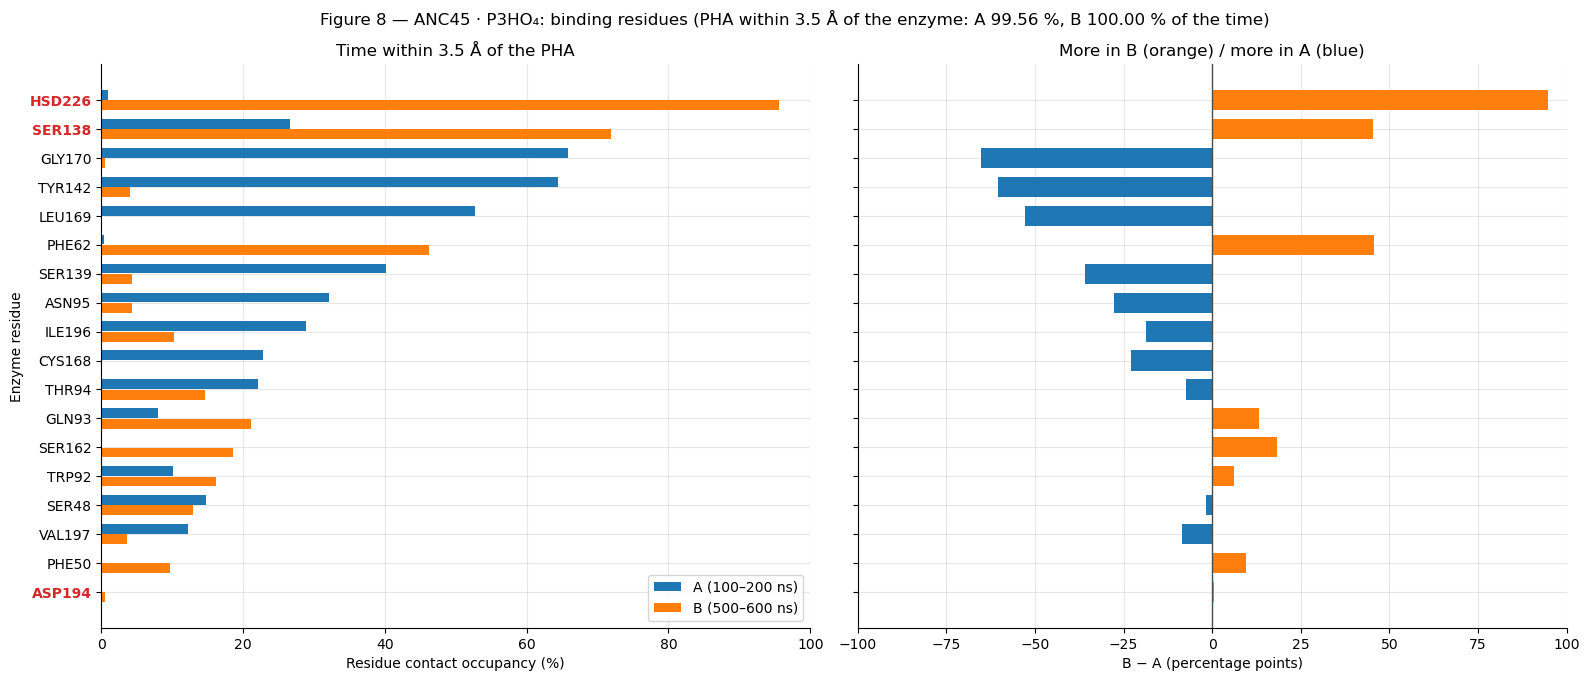

,resname,resid,A_occupancy_percent,B_occupancy_percent,change_B_minus_A
225,HSD,226,0.91,95.62,94.71
137,SER,138,26.56,71.86,45.30
169,GLY,170,65.83,0.60,-65.23
141,TYR,142,64.45,4.10,-60.35
168,LEU,169,52.78,0.00,-52.78
61,PHE,62,0.45,46.19,45.74
138,SER,139,40.15,4.34,-35.81
94,ASN,95,32.06,4.40,-27.66
195,ILE,196,28.84,10.19,-18.65
167,CYS,168,22.85,0.00,-22.85


Method check passed: 100–200 / 400–500 ns values of GLY170, SER138, HSD226 and global [99.56, 98.53] reproduced.
Global time within 3.5 Å in the current windows: {'A': 99.56, 'B': 100.0}


In [5]:
occ = residues[['resindex', 'resid', 'resname']].copy()
occ['A_occupancy_percent'] = PROFILES['A'] * 100
occ['B_occupancy_percent'] = PROFILES['B'] * 100
occ['change_B_minus_A'] = occ.B_occupancy_percent - occ.A_occupancy_percent
GLOBAL_WITHIN = {}
for k, (s, e) in WINDOWS.items():
    gt, gv = clip_series(T, GMIN, s, e)
    GLOBAL_WITHIN[k] = float(100 * contact_duration(gt, gv, CONTACT_CUTOFF_A) / (e - s))

# Method check: for its windows (100-200 and 400-500 ns) the method must reproduce enzyme_p3ho4_binding_modes.ipynb.
REFERENCE_WINDOWS = ((100.0, 200.0), (400.0, 500.0))
REFERENCE = {('GLY', 170): (65.83, 5.00), ('SER', 138): (26.56, 55.65), ('HSD', 226): (0.91, 41.73)}
ref_occ = [window_occupancy(w) for w in REFERENCE_WINDOWS]
ref_global = [100 * contact_duration(*clip_series(T, GMIN, *w), CONTACT_CUTOFF_A) / (w[1] - w[0]) for w in REFERENCE_WINDOWS]
bad = []
for (resname, resid), ref in REFERENCE.items():
    i = int(np.flatnonzero((residues.resname == resname).to_numpy() & (residues.resid == resid).to_numpy())[0])
    got = (ref_occ[0][i], ref_occ[1][i])
    if not np.allclose(got, ref, atol=0.006): bad.append(f'{resname}{resid}: {got} vs {ref}')
if not np.allclose(ref_global, (99.56, 98.53), atol=0.006):
    bad.append(f'global time within 3.5 Å: {ref_global}')
if bad: raise ValueError('Occupancies differ from enzyme_p3ho4_binding_modes.ipynb:\n' + '\n'.join(bad))

# State-based: fraction of ALL frames labelled A (or B) in Figure 7 with the residue within the cutoff.
for k in ('A', 'B'):
    occ[f'state_{k}_occupancy_percent'] = 100 * (DIST[STATE_LABELS == k] <= CONTACT_CUTOFF_A).mean(axis=0)

TRIAD_IDS = [resid for _, resid in TRIAD.values()]
keep = occ.resid.isin(TRIAD_IDS).to_numpy()
for k in WINDOWS:
    col = f'{k}_occupancy_percent'
    keep |= occ[col].to_numpy() >= PROMINENT_PERCENT
    keep[occ.loc[occ[col] > 0].sort_values([col, 'resindex'], ascending=[False, True]).head(TOP_N).index] = True
occ['shown_in_figure'] = keep
occ['catalytic_triad'] = occ.resid.isin(TRIAD_IDS)
table8 = occ.loc[keep].assign(_max=lambda x: x[['A_occupancy_percent', 'B_occupancy_percent']].max(axis=1))
table8 = table8.sort_values(['_max', 'resindex'], ascending=[False, True]).drop(columns='_max')
y = np.arange(len(table8)); labels8 = (table8.resname + table8.resid.astype(str)).tolist()

fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], max(FIGSIZE[1], 0.3 * len(table8) + 1.5)), sharey=True)
for offset, k in [(-0.18, 'A'), (0.18, 'B')]:
    axes[0].barh(y + offset, table8[f'{k}_occupancy_percent'], height=0.34, color=COLOURS[k],
                 label=f'{k} ({WINDOWS[k][0]:g}–{WINDOWS[k][1]:g} ns)')
delta = table8.change_B_minus_A.to_numpy()
axes[1].barh(y, delta, height=0.7, color=np.where(delta >= 0, COLOURS['B'], COLOURS['A']))
axes[1].axvline(0, color='0.3', lw=1)
axes[0].set(yticks=y, yticklabels=labels8, xlim=(0, 100), xlabel='Residue contact occupancy (%)', ylabel='Enzyme residue',
            title=f'Time within {CONTACT_CUTOFF_A:g} Å of the PHA')
axes[1].set(xlim=(-100, 100), xlabel='B − A (percentage points)', title='More in B (orange) / more in A (blue)')
axes[0].invert_yaxis(); axes[0].legend(loc='lower right')
for tick, is_triad in zip(axes[0].get_yticklabels(), table8.catalytic_triad):
    if is_triad: tick.set_color(TRIAD_COLOUR); tick.set_fontweight('bold')
for ax in axes: tidy(ax)
fig.suptitle(f"Figure 8 — ANC45 · P3HO₄: binding residues (PHA within {CONTACT_CUTOFF_A:g} Å of the enzyme: "
             f"A {GLOBAL_WITHIN['A']:.2f} %, B {GLOBAL_WITHIN['B']:.2f} % of the time)")
fig.tight_layout()
save_png(fig, 'fig8_binding_residues.png')
display(fig); plt.close(fig)
save_csv(occ, 'fig8_residue_occupancy_all.csv')
save_csv(table8, 'fig8_residues_shown.csv')
display(table8[['resname', 'resid', 'A_occupancy_percent', 'B_occupancy_percent', 'change_B_minus_A']].round(2))
print('Method check passed: 100–200 / 400–500 ns values of', ', '.join(f'{r}{i}' for r, i in REFERENCE),
      'and global', [round(float(v), 2) for v in ref_global], 'reproduced.')
print('Global time within 3.5 Å in the current windows:', {k: round(float(v), 2) for k, v in GLOBAL_WITHIN.items()})

### Figure 10 — How tightly is the PHA held?

**Question:** how many residues and hydrogen bonds hold the PHA in A and in B? Residue counts within 3.5 Å and 4.5 Å come from the saved residue distances; hydrogen bonds are found with MDAnalysis in every 0.1 ns frame of both windows (donor–acceptor ≤ 3.0 Å, D–H–A angle ≥ 150°, periodic box applied, protein and PHA as donor or acceptor). **How to read it:** left, distributions of residues in contact (solid 3.5 Å, dashed 4.5 Å); middle, hydrogen bonds per frame; right, the most frequent hydrogen-bond partners as % of frames. Means ± SD are in the legends.

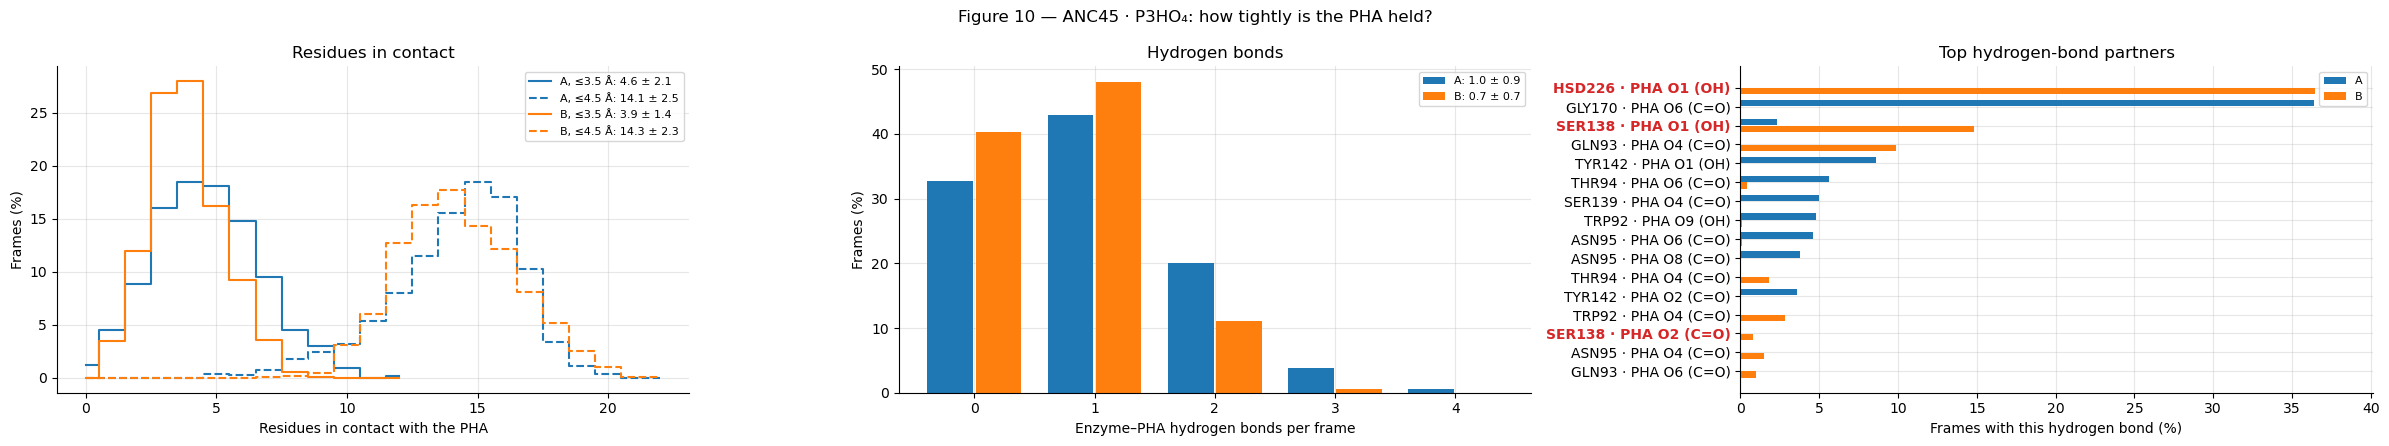

PHA donors used: ['O1–H1', 'O9–H58'] | 382 donor hydrogens, 366 acceptors, 6141 frames


,window,variable,mean,std,median,min,max
0,A,hbonds,0.97,0.85,1.0,0.0,4.0
1,A,residues_within_3p5A,4.64,2.06,5.0,0.0,12.0
2,A,residues_within_4p5A,14.15,2.51,15.0,5.0,20.0
3,B,hbonds,0.72,0.68,1.0,0.0,3.0
4,B,residues_within_3p5A,3.87,1.42,4.0,1.0,9.0
5,B,residues_within_4p5A,14.27,2.27,14.0,7.0,22.0
6,state A (all frames),residues_within_3p5A,4.18,1.92,4.0,1.0,12.0
7,state A (all frames),residues_within_4p5A,13.71,2.64,14.0,5.0,25.0
8,state A (all frames),hbonds,0.72,0.77,1.0,0.0,4.0
9,state B (all frames),residues_within_3p5A,3.58,1.56,3.0,1.0,10.0


In [6]:
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

window_of = {k: in_window(T, w) for k, w in WINDOWS.items()}
contacts = pd.concat([pd.DataFrame({'frame': FRAMES[m], 'time_ns': T[m], 'window': k,
                                    'residues_within_3p5A': (DIST[m] <= CONTACT_CUTOFF_A).sum(axis=1),
                                    'residues_within_4p5A': (DIST[m] <= WIDE_CUTOFF_A).sum(axis=1)})
                      for k, m in window_of.items()], ignore_index=True)

# Hydrogen bonds. Donor hydrogens: every H bonded to N or O (protein; PHA hydroxyl/acid OH).
# Acceptors: all protein O, protein side-chain N without H (e.g. HSD NE2), and all PHA oxygens.
PROTEIN = U.select_atoms('protein')
polar_h = [a.index for a in PROTEIN + LIG
           if a.element == 'H' and len(a.bonded_atoms) == 1 and a.bonded_atoms[0].element in ('N', 'O')]
acceptors = [a.index for a in PROTEIN
             if a.element == 'O' or (a.element == 'N' and a.name != 'N' and 'H' not in a.bonded_atoms.elements)]
acceptors += list(LIG.select_atoms('element O').indices)
LIG_DONORS = [f'{U.atoms[i].bonded_atoms[0].name}–{U.atoms[i].name}' for i in polar_h if U.atoms[i].resname == 'LIG']
GROUPS10 = {f'window {k}': window_of[k] for k in WINDOWS} | {f'state {k}': STATE_LABELS == k for k in ('A', 'B')}
hb_mask = np.logical_or.reduce(list(GROUPS10.values()))
hb_frames = [int(f) for f in FRAMES[hb_mask]]
hba = HydrogenBondAnalysis(U, between=['protein', 'resname LIG'],
                           hydrogens_sel='index ' + ' '.join(map(str, polar_h)),
                           acceptors_sel='index ' + ' '.join(map(str, acceptors)),
                           d_a_cutoff=HBOND_DA_CUTOFF_A, d_h_a_angle_cutoff=HBOND_ANGLE_DEG, update_selections=False)
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='No hydrogen bonds were found')   # printed for frames without any H-bond
    hba.run(frames=hb_frames)

O_ROLE = {'OG2D1': 'C=O', 'OG302': 'ester O', 'OG311': 'OH'}
def pha_atom(a): return f"{a.name} ({O_ROLE.get(a.type, a.type)})"
rows = []
for frame, d, h, acc, dist, ang in hba.results.hbonds:
    donor, acceptor = U.atoms[int(d)], U.atoms[int(acc)]
    prot, pha = (donor, acceptor) if donor.resname != 'LIG' else (acceptor, donor)
    rows.append({'frame': int(frame), 'donor': f'{donor.resname}{donor.resid}:{donor.name}',
                 'acceptor': f'{acceptor.resname}{acceptor.resid}:{acceptor.name}',
                 'direction': 'protein donor' if donor.resname != 'LIG' else 'PHA donor',
                 'protein_residue': f'{prot.resname}{prot.resid}', 'protein_atom': prot.name,
                 'partner': f'{prot.resname}{prot.resid} · PHA {pha_atom(pha)}',
                 'distance_A': dist, 'angle_deg': ang})
hbonds = pd.DataFrame(rows, columns=['frame', 'donor', 'acceptor', 'direction', 'protein_residue', 'protein_atom',
                                     'partner', 'distance_A', 'angle_deg'])
frame_time = dict(zip(FRAMES, T))
hbonds.insert(1, 'time_ns', hbonds.frame.map(frame_time))
hbonds.insert(2, 'state', STATE_LABELS[hbonds.frame.to_numpy() - FRAMES[0]] if len(hbonds) else [])
for k in WINDOWS: hbonds[f'in_window_{k}'] = in_window(hbonds.time_ns, WINDOWS[k])
HB_PER_FRAME = np.full(len(T), np.nan); HB_PER_FRAME[hb_mask] = 0     # NaN = frame not analysed
counts = hbonds.groupby('frame').size()
HB_PER_FRAME[counts.index.to_numpy() - FRAMES[0]] = counts.to_numpy()
contacts['hbonds'] = HB_PER_FRAME[contacts.frame.to_numpy() - FRAMES[0]].astype(int)

def partner_percent(mask):
    sel = hbonds.frame.isin(FRAMES[mask])
    return hbonds.loc[sel].groupby('partner').frame.nunique() / int(mask.sum()) * 100
partners = pd.concat([partner_percent(m).rename(f"{g.replace(' ', '_')}_percent_frames") for g, m in GROUPS10.items()], axis=1).fillna(0.0)
partners = partners.rename(columns={f'window_{k}_percent_frames': f'{k}_percent_frames' for k in WINDOWS})
top = set()
for k in WINDOWS: top |= set(partners[f'{k}_percent_frames'].nlargest(8).index[partners[f'{k}_percent_frames'].nlargest(8) > 0])
partners_shown = partners.loc[sorted(top, key=lambda p: -partners.loc[p].max())]

stats10 = (contacts.melt(id_vars=['window'], value_vars=['residues_within_3p5A', 'residues_within_4p5A', 'hbonds'])
           .groupby(['window', 'variable']).value.agg(['mean', 'std', 'median', 'min', 'max']).reset_index())
def ms(k, col):
    v = contacts.loc[contacts.window == k, col]; return f'{v.mean():.1f} ± {v.std():.1f}'

fig, axes = plt.subplots(1, 3, figsize=(3 * FIGSIZE[0], FIGSIZE[1]))
ax = axes[0]
for k in WINDOWS:
    for col, ls, cut in [('residues_within_3p5A', '-', CONTACT_CUTOFF_A), ('residues_within_4p5A', '--', WIDE_CUTOFF_A)]:
        v = contacts.loc[contacts.window == k, col].to_numpy()
        frac = np.bincount(v, minlength=contacts[col].max() + 1) / len(v) * 100
        ax.step(np.arange(len(frac)), frac, where='mid', color=COLOURS[k], ls=ls, lw=1.5,
                label=f'{k}, ≤{cut:g} Å: {ms(k, col)}')
ax.set(xlabel='Residues in contact with the PHA', ylabel='Frames (%)', title='Residues in contact')
ax.legend(fontsize=8)
ax = axes[1]
xmax = int(contacts.hbonds.max())
for offset, k in [(-0.2, 'A'), (0.2, 'B')]:
    v = contacts.loc[contacts.window == k, 'hbonds'].to_numpy()
    ax.bar(np.arange(xmax + 1) + offset, np.bincount(v, minlength=xmax + 1) / len(v) * 100, width=0.38,
           color=COLOURS[k], label=f'{k}: {ms(k, "hbonds")}')
ax.set(xticks=range(xmax + 1), xlabel='Enzyme–PHA hydrogen bonds per frame', ylabel='Frames (%)', title='Hydrogen bonds')
ax.legend(fontsize=8)
ax = axes[2]
yy = np.arange(len(partners_shown))
for offset, k in [(-0.18, 'A'), (0.18, 'B')]:
    ax.barh(yy + offset, partners_shown[f'{k}_percent_frames'], height=0.34, color=COLOURS[k], label=k)
ax.set(yticks=yy, yticklabels=partners_shown.index, xlabel='Frames with this hydrogen bond (%)',
       title='Top hydrogen-bond partners', xlim=(0, max(5, partners_shown.values.max() * 1.1)))
ax.invert_yaxis(); ax.legend(fontsize=8)
for tick in ax.get_yticklabels():
    if any(tick.get_text().startswith(f'{r}{i} ') for r, i in TRIAD.values()):
        tick.set_color(TRIAD_COLOUR); tick.set_fontweight('bold')
for ax in axes: tidy(ax)
fig.suptitle('Figure 10 — ANC45 · P3HO₄: how tightly is the PHA held?')
fig.tight_layout()
save_png(fig, 'fig10_contacts_hbonds.png')
display(fig); plt.close(fig)
save_csv(contacts, 'fig10_contacts_hbonds_per_frame.csv')
save_csv(hbonds, 'fig10_hbonds_all.csv')
save_csv(partners.reset_index(names='partner').sort_values('B_percent_frames', ascending=False), 'fig10_hbond_partners.csv')

# State-based: the same numbers for ALL frames labelled A or B in Figure 7.
N35_ALL = (DIST <= CONTACT_CUTOFF_A).sum(axis=1); N45_ALL = (DIST <= WIDE_CUTOFF_A).sum(axis=1)
state_rows = []
for k in ('A', 'B'):
    m = STATE_LABELS == k
    for name, v in [('residues_within_3p5A', N35_ALL[m]), ('residues_within_4p5A', N45_ALL[m]), ('hbonds', HB_PER_FRAME[m])]:
        state_rows.append({'window': f'state {k} (all frames)', 'variable': name, 'mean': v.mean(), 'std': v.std(ddof=1),
                           'median': np.median(v), 'min': v.min(), 'max': v.max()})
stats10 = pd.concat([stats10, pd.DataFrame(state_rows)], ignore_index=True)
save_csv(stats10, 'fig10_summary.csv')
print('PHA donors used:', LIG_DONORS, f'| {len(polar_h)} donor hydrogens, {len(acceptors)} acceptors, {len(hb_frames)} frames')
display(stats10.round(2))

### Figure 11 — Is the PHA in a position to be cut?

**Question:** how often is a PHA carbonyl carbon close to the catalytic serine while the serine–histidine link is intact? Per frame (0–1000 ns, PBC-aware, unaligned coordinates): d1 = Ser138 OG to the nearest of the four LIG CG2O2 carbons, d2 = Ser138 OG to HSD226 NE2, d3 = HSD226 ND1 to the nearest Asp194 carboxylate oxygen. **How to read it:** the top panel shows d1–d3 over time with the Figure 7 state strip below; the bottom panels show d1 in A and B and the % of frames that are "ready to react" (d1 ≤ 3.5 Å and d2 ≤ 3.5 Å). This is a simple distance criterion, not a reaction energy.

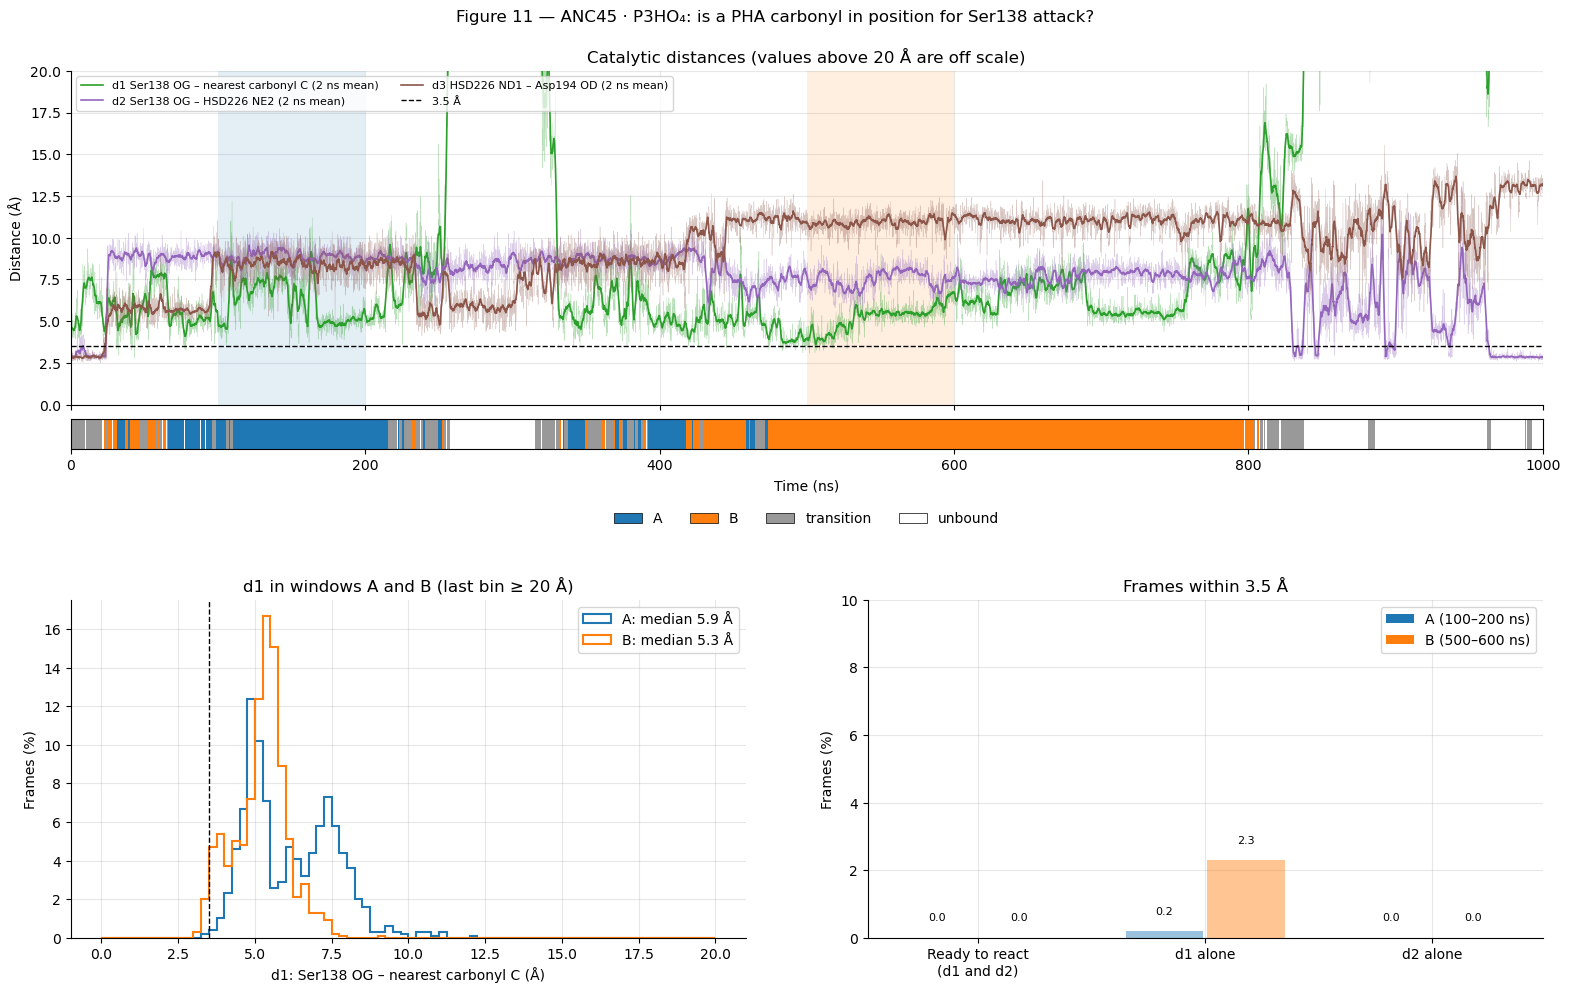

,group,frames,ready_percent,ready_ester_only_percent,ready_and_d3_within_percent,d1_within_percent,d2_within_percent,d3_within_percent,d1_median_A,d2_median_A,d3_median_A
0,window A,1001,0.0,0.0,0.0,0.20,0.00,0.00,5.94,8.88,8.49
1,window B,1001,0.0,0.0,0.0,2.30,0.00,0.00,5.32,7.57,10.98
2,state A,2064,0.0,0.0,0.0,0.39,0.05,0.05,5.33,8.81,8.33
3,state B,4029,0.0,0.0,0.0,1.44,0.55,0.57,5.67,7.73,10.97
4,state transition,1568,0.0,0.0,0.0,0.06,20.03,13.46,7.81,8.25,8.58
5,state unbound,2340,0.0,0.0,0.0,0.00,18.50,0.13,51.61,7.19,9.58
6,all 0-1000 ns,10001,0.0,0.0,0.0,0.67,7.70,2.38,6.59,8.00,9.99


,window,nearest_carbonyl,percent_frames,kind
0,A,C32,38.8,acid end
1,A,C8,37.2,ester
2,A,C16,23.5,ester
3,A,C24,0.6,ester
4,B,C8,99.3,ester
5,B,C16,0.6,ester
6,B,C32,0.1,acid end


In [7]:
from MDAnalysis.lib.distances import distance_array

og, ne2, nd1 = ATOMS['SER138_OG'], ATOMS['HSD226_NE2'], ATOMS['HSD226_ND1']
od = ATOMS['ASP194_OD1'] + ATOMS['ASP194_OD2']
d1 = np.empty(len(T)); d1_ester = np.empty(len(T)); d2 = np.empty(len(T)); d3 = np.empty(len(T)); nearest = []
is_ester = np.array([CARBONYL_KIND[a.name] == 'ester' for a in CARBONYL_C])
for i, ts in enumerate(U.trajectory[int(FRAMES[0]):int(FRAMES[-1]) + 1]):
    if not np.isclose(ts.time / 1000, T[i], atol=1e-6): raise ValueError('Frame/time mismatch')
    box = ts.dimensions
    dc = distance_array(og.positions, CARBONYL_C.positions, box=box)[0]
    j = int(np.argmin(dc)); d1[i] = dc[j]; d1_ester[i] = dc[is_ester].min(); nearest.append(CARBONYL_C[j].name)
    d2[i] = distance_array(og.positions, ne2.positions, box=box)[0, 0]
    d3[i] = distance_array(nd1.positions, od.positions, box=box).min()
U.trajectory[0]
ready = (d1 <= READY_CUTOFF_A) & (d2 <= READY_CUTOFF_A)
geo = pd.DataFrame({'frame': FRAMES, 'time_ns': T, 'd1_SerOG_carbonylC_A': d1, 'nearest_carbonyl': nearest,
                    'nearest_carbonyl_kind': [CARBONYL_KIND[n] for n in nearest], 'd1_ester_only_A': d1_ester,
                    'd2_SerOG_HisNE2_A': d2, 'd3_HisND1_AspOD_A': d3, 'ready_to_react': ready,
                    'state': STATE_LABELS})

def ready_row(group, mask):
    n = int(mask.sum())
    return {'group': group, 'frames': n,
            'ready_percent': 100 * ready[mask].mean() if n else np.nan,
            'ready_ester_only_percent': 100 * ((d1_ester <= READY_CUTOFF_A) & (d2 <= READY_CUTOFF_A))[mask].mean() if n else np.nan,
            'ready_and_d3_within_percent': 100 * (ready & (d3 <= READY_CUTOFF_A))[mask].mean() if n else np.nan,
            'd1_within_percent': 100 * (d1 <= READY_CUTOFF_A)[mask].mean() if n else np.nan,
            'd2_within_percent': 100 * (d2 <= READY_CUTOFF_A)[mask].mean() if n else np.nan,
            'd3_within_percent': 100 * (d3 <= READY_CUTOFF_A)[mask].mean() if n else np.nan,
            'd1_median_A': float(np.median(d1[mask])) if n else np.nan,
            'd2_median_A': float(np.median(d2[mask])) if n else np.nan,
            'd3_median_A': float(np.median(d3[mask])) if n else np.nan}
ready_table = pd.DataFrame([ready_row(f'window {k}', window_of[k]) for k in WINDOWS] +
                           [ready_row(f'state {s}', STATE_LABELS == s) for s in STATES] +
                           [ready_row('all 0-1000 ns', np.ones(len(T), bool))])
nearest_table = (geo.assign(window=np.select([window_of['A'], window_of['B']], ['A', 'B'], 'other'))
                 .query("window != 'other'").groupby('window').nearest_carbonyl.value_counts(normalize=True)
                 .mul(100).rename('percent_frames').reset_index())
nearest_table['kind'] = nearest_table.nearest_carbonyl.map(CARBONYL_KIND)

fig = plt.figure(figsize=(2 * FIGSIZE[0], 2 * FIGSIZE[1] + 1.2))
outer = fig.add_gridspec(2, 1, height_ratios=[1.12, 1], hspace=0.42)
top = outer[0].subgridspec(2, 1, height_ratios=[1, 0.09], hspace=0.08)
bottom = outer[1].subgridspec(1, 2, wspace=0.18)
ax = fig.add_subplot(top[0]); shade_windows(ax)
roll = lambda v: pd.Series(v).rolling(n_roll, center=True, min_periods=1).mean()
for v, colour, name in [(d1, 'tab:green', 'd1 Ser138 OG – nearest carbonyl C'), (d2, 'tab:purple', 'd2 Ser138 OG – HSD226 NE2'),
                        (d3, 'tab:brown', 'd3 HSD226 ND1 – Asp194 OD')]:
    ax.plot(T, v, color=colour, lw=0.3, alpha=0.35)
    ax.plot(T, roll(v), color=colour, lw=1.2, label=f'{name} ({SMOOTH_NS:g} ns mean)')
ax.axhline(READY_CUTOFF_A, color='k', ls='--', lw=1, label=f'{READY_CUTOFF_A:g} Å')
ax.set(ylabel='Distance (Å)', ylim=(0, 20), xlim=(T[0], T[-1]), title='Catalytic distances (values above 20 Å are off scale)')
ax.legend(loc='upper left', fontsize=8, ncol=2); tidy(ax); ax.tick_params(labelbottom=False)
strip = fig.add_subplot(top[1], sharex=ax); draw_state_strip(strip, STATE_LABELS); strip.set_xlabel('Time (ns)')
ax = fig.add_subplot(bottom[0])
bins = np.arange(0, 20.25, 0.25)
for k in WINDOWS:
    v = np.clip(d1[window_of[k]], 0, bins[-1] - 1e-9)
    ax.hist(v, bins=bins, weights=np.full(len(v), 100 / len(v)), histtype='step', lw=1.5, color=COLOURS[k],
            label=f'{k}: median {np.median(d1[window_of[k]]):.1f} Å')
ax.axvline(READY_CUTOFF_A, color='k', ls='--', lw=1)
ax.set(xlabel='d1: Ser138 OG – nearest carbonyl C (Å)', ylabel='Frames (%)', title='d1 in windows A and B (last bin ≥ 20 Å)')
ax.legend(); tidy(ax)
ax = fig.add_subplot(bottom[1])
# Ready to react (both conditions) is the result; d1 and d2 alone are shown for context.
groups = [('ready_percent', 'Ready to react\n(d1 and d2)'), ('d1_within_percent', 'd1 alone'), ('d2_within_percent', 'd2 alone')]
rt11 = ready_table.set_index('group'); top_val = 0
for g, (col, name) in enumerate(groups):
    for offset, k in [(-0.18, 'A'), (0.18, 'B')]:
        v = rt11.loc[f'window {k}', col]; top_val = max(top_val, v)
        ax.bar(g + offset, v, width=0.34, color=COLOURS[k], alpha=1 if g == 0 else 0.45,
               label=f'{k} ({WINDOWS[k][0]:g}–{WINDOWS[k][1]:g} ns)' if g == 0 else None)
        ax.text(g + offset, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
ax.set(xticks=range(len(groups)), xticklabels=[n for _, n in groups], ylabel='Frames (%)',
       ylim=(0, max(10, top_val * 1.2)), title=f'Frames within {READY_CUTOFF_A:g} Å')
ax.legend(); tidy(ax)
fig.suptitle('Figure 11 — ANC45 · P3HO₄: is a PHA carbonyl in position for Ser138 attack?')
fig.subplots_adjust(top=0.92, bottom=0.07, left=0.06, right=0.98)
save_png(fig, 'fig11_catalytic_geometry.png')
display(fig); plt.close(fig)
save_csv(geo, 'fig11_catalytic_distances.csv')
save_csv(ready_table, 'fig11_ready_to_react.csv')
save_csv(nearest_table, 'fig11_nearest_carbonyl.csv')
display(ready_table.round(2)); display(nearest_table.round(1))

### Summary

The cell below collects the key numbers from Figures 7, 8, 10 and 11, generated from this run. The first table uses the two 100 ns windows. The second, state-based table uses all frames labelled A or B in Figure 7, so it does not depend on which 100 ns windows were picked.

In [8]:
t7 = main7['table'].set_index('state'); rt = ready_table.set_index('group'); st10 = stats10.set_index(['window', 'variable'])
def msd(group, var): return f"{st10.loc[(group, var), 'mean']:.1f} ± {st10.loc[(group, var), 'std']:.1f}"
def top_res(col, n=4): return ', '.join(f"{r.resname}{r.resid} {r[col]:.0f}" for _, r in occ.nlargest(n, col).iterrows())
def triad_occ(col): return ', '.join(f"{r.resname}{r.resid} {r[col]:.0f}" for _, r in occ.loc[occ.catalytic_triad].iterrows())
def top_partner(col): p = partners[col].idxmax(); return f"{p} ({partners.loc[p, col]:.0f} %)"

wA, wB = (f'{k} ({WINDOWS[k][0]:g}–{WINDOWS[k][1]:g} ns)' for k in WINDOWS)
win = ['**Window-based** (the two 100 ns windows)', '', f'| | {wA} | {wB} |', '|---|---|---|',
       '| Top residues (occupancy %) | ' + ' | '.join(top_res(f'{k}_occupancy_percent') for k in WINDOWS) + ' |',
       '| Triad occupancy (%) | ' + ' | '.join(triad_occ(f'{k}_occupancy_percent') for k in WINDOWS) + ' |',
       f"| Residues within 3.5 Å per frame | {msd('A','residues_within_3p5A')} | {msd('B','residues_within_3p5A')} |",
       f"| Residues within 4.5 Å per frame | {msd('A','residues_within_4p5A')} | {msd('B','residues_within_4p5A')} |",
       f"| Hydrogen bonds per frame | {msd('A','hbonds')} | {msd('B','hbonds')} |",
       '| Top hydrogen-bond partner (% frames) | ' + ' | '.join(top_partner(f'{k}_percent_frames') for k in WINDOWS) + ' |',
       f"| d1 Ser138 OG – carbonyl C ≤ {READY_CUTOFF_A:g} Å (% frames) | {rt.loc['window A','d1_within_percent']:.1f} | {rt.loc['window B','d1_within_percent']:.1f} |",
       f"| d2 Ser138 OG – HSD226 NE2 ≤ {READY_CUTOFF_A:g} Å (% frames) | {rt.loc['window A','d2_within_percent']:.1f} | {rt.loc['window B','d2_within_percent']:.1f} |",
       f"| Ready to react (% frames) | {rt.loc['window A','ready_percent']:.1f} | {rt.loc['window B','ready_percent']:.1f} |"]
sA, sB = 'state A (all frames)', 'state B (all frames)'
sta = ['**State-based** (all frames labelled A or B in Figure 7, 0–1000 ns)', '', '| | State A | State B |', '|---|---|---|',
       f"| Time in state (ns) | {t7.loc['A','total_time_ns']:.1f} | {t7.loc['B','total_time_ns']:.1f} |",
       f"| Longest clean block (ns) | {t7.loc['A','longest_segment_ns']:.1f} ({t7.loc['A','longest_from_ns']:g}–{t7.loc['A','longest_to_ns']:g}) | "
       f"{t7.loc['B','longest_segment_ns']:.1f} ({t7.loc['B','longest_from_ns']:g}–{t7.loc['B','longest_to_ns']:g}) |",
       f"| Segments (≥ {MIN_SEGMENT_NS:g} ns after merging) | {t7.loc['A','segments']} | {t7.loc['B','segments']} |",
       '| Top residues (% frames) | ' + ' | '.join(top_res(f'state_{k}_occupancy_percent') for k in 'AB') + ' |',
       '| Triad occupancy (% frames) | ' + ' | '.join(triad_occ(f'state_{k}_occupancy_percent') for k in 'AB') + ' |',
       f"| Residues within 3.5 Å per frame | {msd(sA,'residues_within_3p5A')} | {msd(sB,'residues_within_3p5A')} |",
       f"| Residues within 4.5 Å per frame | {msd(sA,'residues_within_4p5A')} | {msd(sB,'residues_within_4p5A')} |",
       f"| Hydrogen bonds per frame | {msd(sA,'hbonds')} | {msd(sB,'hbonds')} |",
       '| Top hydrogen-bond partner (% frames) | ' + ' | '.join(top_partner(f'state_{k}_percent_frames') for k in 'AB') + ' |',
       f"| d1 ≤ {READY_CUTOFF_A:g} Å (% frames) | {rt.loc['state A','d1_within_percent']:.1f} | {rt.loc['state B','d1_within_percent']:.1f} |",
       f"| d2 ≤ {READY_CUTOFF_A:g} Å (% frames) | {rt.loc['state A','d2_within_percent']:.1f} | {rt.loc['state B','d2_within_percent']:.1f} |",
       f"| Ready to react (% frames) | {rt.loc['state A','ready_percent']:.1f} | {rt.loc['state B','ready_percent']:.1f} |"]
other = (f"Transition time {t7.loc['transition','total_time_ns']:.1f} ns; unbound time {t7.loc['unbound','total_time_ns']:.1f} ns. "
         f"Starting pose (0–{START_POSE_NS:g} ns) similarity: A {START_SIM['A']:.2f}, B {START_SIM['B']:.2f}.")
summary_rows = [dict(zip(['basis', 'metric', 'A', 'B'], [basis] + [c.strip() for c in l.strip('|').split('|')]))
                for basis, table in [(f'window A {WINDOWS["A"]}, B {WINDOWS["B"]} ns', win), ('state (all labelled frames)', sta)] for l in table[4:]]
save_csv(pd.DataFrame(summary_rows), 'summary_window_and_state_based.csv')
display(Markdown('\n'.join(win) + '\n\n' + '\n'.join(sta) + f"\n\n{other}\n\nState changes ({SMOOTH_NS:g} ns smoothing, segments < {MIN_SEGMENT_NS:g} ns merged, transition segments skipped): {describe_changes(main7['changes'])}."))

**Window-based** (the two 100 ns windows)

| | A (100–200 ns) | B (500–600 ns) |
|---|---|---|
| Top residues (occupancy %) | GLY170 66, TYR142 64, LEU169 53, SER139 40 | HSD226 96, SER138 72, PHE62 46, GLN93 21 |
| Triad occupancy (%) | SER138 27, ASP194 0, HSD226 1 | SER138 72, ASP194 1, HSD226 96 |
| Residues within 3.5 Å per frame | 4.6 ± 2.1 | 3.9 ± 1.4 |
| Residues within 4.5 Å per frame | 14.1 ± 2.5 | 14.3 ± 2.3 |
| Hydrogen bonds per frame | 1.0 ± 0.9 | 0.7 ± 0.7 |
| Top hydrogen-bond partner (% frames) | GLY170 · PHA O6 (C=O) (36 %) | HSD226 · PHA O1 (OH) (36 %) |
| d1 Ser138 OG – carbonyl C ≤ 3.5 Å (% frames) | 0.2 | 2.3 |
| d2 Ser138 OG – HSD226 NE2 ≤ 3.5 Å (% frames) | 0.0 | 0.0 |
| Ready to react (% frames) | 0.0 | 0.0 |

**State-based** (all frames labelled A or B in Figure 7, 0–1000 ns)

| | State A | State B |
|---|---|---|
| Time in state (ns) | 206.4 | 402.9 |
| Longest clean block (ns) | 157.8 (57.8–215.6) | 340.6 (471.6–812.2) |
| Segments (≥ 5 ns after merging) | 6 | 4 |
| Top residues (% frames) | TYR142 50, LEU169 48, GLY170 45, SER138 37 | HSD226 78, SER138 55, PHE62 42, SER48 24 |
| Triad occupancy (% frames) | SER138 37, ASP194 0, HSD226 7 | SER138 55, ASP194 3, HSD226 78 |
| Residues within 3.5 Å per frame | 4.2 ± 1.9 | 3.6 ± 1.6 |
| Residues within 4.5 Å per frame | 13.7 ± 2.6 | 14.0 ± 3.1 |
| Hydrogen bonds per frame | 0.7 ± 0.8 | 0.6 ± 0.7 |
| Top hydrogen-bond partner (% frames) | GLY170 · PHA O6 (C=O) (18 %) | HSD226 · PHA O1 (OH) (26 %) |
| d1 ≤ 3.5 Å (% frames) | 0.4 | 1.4 |
| d2 ≤ 3.5 Å (% frames) | 0.0 | 0.5 |
| Ready to react (% frames) | 0.0 | 0.0 |

Transition time 156.8 ns; unbound time 233.9 ns. Starting pose (0–5 ns) similarity: A 0.42, B 0.35.

State changes (2 ns smoothing, segments < 5 ns merged, transition segments skipped): B → A at ~31.2 ns; A → B at ~36.7 ns; B → A at ~57.8 ns; A → unbound → A (249.6–315.4 ns); A → B at ~417.8 ns; B → A at ~458.6 ns; A → B (464.4–471.6 ns); B → unbound (to end of run) (837.4–1000 ns).

### Provenance and limitations

This cell writes `provenance.json` (input fingerprints, settings, software versions and the list of saved files) and closes the trajectory.

In [9]:
import sys, MDAnalysis
U.trajectory.close(); shutil.rmtree(SCRATCH, ignore_errors=True)
inputs = {k: file_record(p, digest=k != 'xtc') for k, p in PATHS.items()}   # XTC: size and mtime, checked against Figure 3 provenance
if {k: file_record(PATHS[k]) for k in ('tpr', 'xtc')} != {k: {kk: inputs[k][kk] for kk in ('path', 'size', 'mtime_ns')} for k in ('tpr', 'xtc')}:
    raise RuntimeError('Inputs changed during the run')
provenance = {
    'notebook': 'src/md_simulation_scripts/enzyme_pha_analysis/ANC45_P3HO4_binding_modes.ipynb',
    'run_tag': RUN_TAG, 'created': datetime.now().isoformat(timespec='seconds'), 'output_dir': str(OUTPUT_DIR),
    'inputs': inputs,
    'settings': {'windows_ns': WINDOWS, 'contact_cutoff_A': CONTACT_CUTOFF_A, 'wide_cutoff_A': WIDE_CUTOFF_A,
                 'triad': {k: f'{r}{i}' for k, (r, i) in TRIAD.items()}, 'smooth_ns': SMOOTH_NS,
                 'smooth_sensitivity_ns': SMOOTH_SENSITIVITY_NS, 'similarity_threshold': SIMILARITY_THRESHOLD,
                 'min_segment_ns': MIN_SEGMENT_NS, 'top_n': TOP_N, 'prominent_percent': PROMINENT_PERCENT,
                 'hbond_da_cutoff_A': HBOND_DA_CUTOFF_A, 'hbond_angle_deg': HBOND_ANGLE_DEG,
                 'ready_cutoff_A': READY_CUTOFF_A, 'start_pose_ns': START_POSE_NS, 'start_pose_similarity': START_SIM,
                 'annotated_blocks': ANNOTATED_BLOCKS, 'carbonyl_carbons': CARBONYL_KIND, 'pha_hbond_donors': LIG_DONORS,
                 'n_donor_hydrogens': len(polar_h), 'n_acceptors': len(acceptors)},
    'software': {'python': sys.version.split()[0], 'platform': platform.platform(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'matplotlib': matplotlib.__version__, 'MDAnalysis': MDAnalysis.__version__},
    'outputs': {p.name: sha256(p) for p in SAVED},
}
path = OUTPUT_DIR / 'provenance.json'
if path.exists(): raise FileExistsError(path)
path.write_text(json.dumps(provenance, indent=2, default=str))
display(Markdown(f'''
**Inputs.** `{PATHS['tpr'].name}`, `{PATHS['xtc'].name}` (0–1000 ns, {DT:g} ns frames) and the saved residue-distance,
residue-table and minimum-distance CSVs (tag `{SOURCE_TAG}`). TPR/XTC size and modification time match the provenance
saved with Figures 3, 5 and 6, and the CSV SHA-256 hashes match the residue-analysis metadata. All fingerprints are in
`provenance.json`; {len(SAVED)} files were saved to `{OUTPUT_DIR}`.

**Previous run.** Run `20261005_134811` used window B = 400–500 ns; its outputs are kept unchanged in its own folder.

**Limitations.**
- One trajectory of one system. All numbers describe this run only; there are no replicas, so no significance is implied.
- Windows A and B were chosen by inspecting the same trajectory. Figure 7 then labels states by similarity to those
  windows, so states are defined relative to A and B, not discovered independently. The cosine similarity between
  the two reference profiles is {cos_ab:.2f} (1 = same residues, 0 = no shared residues); the closer it is to the
  {SIMILARITY_THRESHOLD:g} threshold, the less cleanly frames can be told apart.
- State labels depend on the smoothing window, the 0.5 threshold and the 5 ns merge rule; the 1 ns and 5 ns tables in
  Figure 7 show how much.
- Contacts use minimum heavy-atom distances; hydrogen bonds use geometric criteria only (no energies). PHA donors are
  the two O–H groups ({', '.join(LIG_DONORS)}): the hydroxyl chain end and the carboxylic-acid end.
- Of the four CG2O2 carbons, three are ester carbonyls and one ({', '.join(n for n, k in CARBONYL_KIND.items() if k != 'ester')})
  is the carboxylic-acid chain end, which is not an ester bond. d1 uses all four, as specified;
  `fig11_ready_to_react.csv` also gives the ester-only result.
- "Ready to react" is a distance criterion (d1, d2 ≤ {READY_CUTOFF_A:g} Å). It ignores the attack angle, the oxyanion hole,
  protonation changes and reaction energetics.
'''))


**Inputs.** `step7_production.tpr`, `processed_protein_centered.xtc` (0–1000 ns, 0.1 ns frames) and the saved residue-distance,
residue-table and minimum-distance CSVs (tag `research_0_1000ns`). TPR/XTC size and modification time match the provenance
saved with Figures 3, 5 and 6, and the CSV SHA-256 hashes match the residue-analysis metadata. All fingerprints are in
`provenance.json`; 20 files were saved to `/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/ANC45_P3HO_4_gromacs/analysis/binding_modes_ANC45/20261005_144534`.

**Previous run.** Run `20261005_134811` used window B = 400–500 ns; its outputs are kept unchanged in its own folder.

**Limitations.**
- One trajectory of one system. All numbers describe this run only; there are no replicas, so no significance is implied.
- Windows A and B were chosen by inspecting the same trajectory. Figure 7 then labels states by similarity to those
  windows, so states are defined relative to A and B, not discovered independently. The cosine similarity between
  the two reference profiles is 0.22 (1 = same residues, 0 = no shared residues); the closer it is to the
  0.5 threshold, the less cleanly frames can be told apart.
- State labels depend on the smoothing window, the 0.5 threshold and the 5 ns merge rule; the 1 ns and 5 ns tables in
  Figure 7 show how much.
- Contacts use minimum heavy-atom distances; hydrogen bonds use geometric criteria only (no energies). PHA donors are
  the two O–H groups (O1–H1, O9–H58): the hydroxyl chain end and the carboxylic-acid end.
- Of the four CG2O2 carbons, three are ester carbonyls and one (C32)
  is the carboxylic-acid chain end, which is not an ester bond. d1 uses all four, as specified;
  `fig11_ready_to_react.csv` also gives the ester-only result.
- "Ready to react" is a distance criterion (d1, d2 ≤ 3.5 Å). It ignores the attack angle, the oxyanion hole,
  protonation changes and reaction energetics.
